# Guided Project: Building a Conversational Healthcare Assistant AI Agent with Context Engineered Memory

![Healthcare AI Agent](https://i.imgur.com/N0zUCi0.png)

## 🎯 Guided Project: Building a Conversational Healthcare Assistant AI Agent with Context Engineered Memory

This guided project demonstrates how to build a **production-ready conversational healthcare assistant** that helps users with medical inquiries, symptom analysis, and doctor recommendations while maintaining conversational context across multiple interactions.

Unlike traditional chatbots that lose context or hit token limits, this project introduces **memory context engineering** using LangGraph's state management and intelligent message trimming to maintain long-running conversations efficiently.

---

### 📋 Learning Objectives

By completing this project, you will:

- **Build a multi-tool AI agent** that combines web search and RAG-based recommendations
- **Implement guardrails** to ensure healthcare-specific scope validation
- **Design conversational state management** with LangGraph's memory system
- **Apply context engineering techniques** to prevent token limit overflow
- **Optimize tool response handling** through intelligent summarization
- **Create multi-user session support** with thread-based memory

---

### 🏗️ Agent Architecture

This project is divided into **two parts**:

**Part I: Building the Basic Agent**
- Create healthcare-specific tools (web search + doctor recommendations)
- Implement guardrails for scope validation
- Build a stateful conversational agent with LangGraph
- Observe context window growth problem

**Part II: Memory Context Engineering**
- Add intelligent context trimming (keep last N messages)
- Implement tool response summarization
- Optimize memory usage (95% reduction achieved)
- Enable unlimited conversation length

**Architecture Flow:**

```
Part I (Basic Agent):
START → Guardrails → Agent → Tools → Agent (loop) → END

Part II (Optimized Agent):
START → Context Trimmer → Guardrails → Agent → Tools (with summarization) → Context Trimmer (loop) → END
```

Final agent architecture:

![](https://i.imgur.com/HRNXG4b.png)

---

### 🛠️ Technical Stack

| Component | Technology | Purpose |
|-----------|------------|----------|
| **Framework** | LangChain + LangGraph | Agent orchestration and state management |
| **LLM** | GPT-4.1-mini | Reasoning, tool calling, and response generation |
| **Web Search** | Tavily API | Real-time medical information retrieval |
| **Vector Database** | ChromaDB | Doctor profile similarity search |
| **Embeddings** | OpenAI Embeddings | Semantic vector representations |
| **Memory** | MemorySaver | Multi-user session persistence |
| **Guardrails** | Pydantic + Structured Output | Healthcare scope validation |

---

### 📚 What You'll Learn

**1. Tool Design Patterns**
- Creating domain-specific tools with clear interfaces
- Combining external APIs (Tavily) with internal knowledge bases (ChromaDB)
- RAG pipeline implementation for recommendation systems

**2. State Management**
- TypedDict-based state schemas
- Message history with `add_messages` reducer
- Thread-based multi-user session handling

**3. Guardrail Implementation**
- Structured output with Pydantic models
- ALLOW/BLOCK decision logic
- Conditional routing based on validation

**4. Memory Optimization**
- Context window trimming strategies
- Tool response summarization pipelines
- Token-aware message management
- RemoveMessage API for efficient cleanup

**5. Graph Design**
- Multi-node agent architecture
- Conditional edge routing
- Feedback loops for continuous processing
- Checkpointer integration for persistence

---

### 💡 Key Concepts

**Conversational Memory**  
Maintaining context across multiple user turns while managing token budgets efficiently.

**Context Engineering**  
Strategic trimming and summarization of conversation history to stay within LLM context limits.

**Tool Orchestration**  
Intelligent routing between web search and knowledge base retrieval based on query type.

**Guardrails**  
Safety mechanisms that validate query relevance before processing.

**RAG (Retrieval-Augmented Generation)**  
Combining semantic search over doctor profiles with LLM reasoning for personalized recommendations.

**State-Based Agents**  
Using graph-based state machines to manage complex agent workflows.

---

---

## 📦 Environment Setup & Dependencies

### Installation

We install all required packages for building our conversational healthcare assistant.

| Package | Purpose |
|---------|---------|
| `langchain` | Core LangChain framework for agent creation and tool orchestration |
| `langchain-openai` | OpenAI LLM (GPT-4.1-mini) for reasoning and structured outputs |
| `langchain-community` | Community tools including Tavily web search integration |
| `langgraph` | Graph-based agent runtime with state management and checkpointing |
| `langchain-chroma` | ChromaDB vector store integration for doctor profile database |

**Why these specific versions?**  
These versions are tested together for compatibility and stability in production environments.

In [ ]:
!pip install -q langchain==1.2.10
!pip install -q langchain-openai==1.1.10
!pip install -q langchain-community==0.4.1
!pip install -q langgraph==1.0.9
!pip install -q langchain-chroma==1.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.7/502.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

---

## 🔐 API Authentication

### Setting Up API Keys

We securely configure the required API keys using `getpass`, which prompts for input without displaying the keys in notebook output or storing them in the cell.

> **Security Best Practice:** Never hardcode API keys directly in your notebook. Using `getpass` ensures keys stay out of version control and shared outputs.

You will need:
- **OpenAI API Key** — Powers the LLM (GPT-4.1-mini) for reasoning and tool calling. Get yours at [platform.openai.com/api-keys](https://platform.openai.com/api-keys)
- **Tavily API Key** — Enables real-time web search for current medical information. Get yours at [tavily.com](https://tavily.com)

Both keys are stored as environment variables and will be accessible to all LangChain components automatically.

In [ ]:
import os
from getpass import getpass

# OpenAI API Key (for LLM reasoning and embeddings)
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

# Tavily API Key (for web search)
os.environ["TAVILY_API_KEY"] = getpass("Enter your Tavily API key: ")

Enter your OpenAI API key: ··········
Enter your Tavily API key: ··········


---

---

# Part I: Building a Conversational Health Assistant Agentic AI System

---

---

## Build a Health Assistant Agentic AI System with Memory

In this section, we build a **conversational healthcare assistant** that can:

1. **Search the web** for current medical information and health guidelines
2. **Recommend doctors** based on user symptoms using a vector database of medical specialists
3. **Validate healthcare scope** through guardrails that block non-medical queries
4. **Maintain conversation context** across multiple user interactions

### Architecture Overview

The agent follows this workflow:

```
User Query → Guardrails (Validate Healthcare Scope)
              ↓ (if ALLOW)
           Agent Node (LLM Reasoning + Tool Selection)
              ↓
           Tools (Web Search OR Doctor Recommendation)
              ↓
           Agent Node (Process Results → Generate Response)
              ↓
           Final Answer
```

### Key Components We'll Build

1. **Tools** — Web search and doctor recommendation capabilities
2. **Guardrails** — Healthcare scope validation
3. **State** — Conversation memory structure
4. **Nodes** — Processing functions (guardrails, agent, tools)
5. **Graph** — Complete agent workflow with routing logic

Let's begin by creating the tools that power our assistant.

---

## 🔧 Create Tools for AI Agent

### Understanding Tools in LangChain

Tools are **external capabilities** that the AI agent can invoke to accomplish tasks it cannot do through reasoning alone. In our healthcare assistant:

- **Web Search Tool** — Retrieves current medical information from the internet
- **Doctor Recommendation Tool** — Finds relevant specialists from a vector database

### Tool Design Principles

Each tool must have:
1. **Clear purpose** — What specific task does it accomplish?
2. **Well-defined interface** — What inputs does it accept? What outputs does it return?
3. **Docstring documentation** — How should the agent know when to use this tool?
4. **Error handling** — What happens when the tool fails?

### Example Tool Definition

```python
@tool
def my_tool(query: str) -> dict:
    """
    Clear description of what this tool does.
    
    Use this tool when:
    - Specific scenario A
    - Specific scenario B
    
    Args:
        query (str): Description of the input
    
    Returns:
        dict: Description of the output
    """
    # Implementation
    return result
```

The `@tool` decorator automatically:
- Converts the function into a LangChain tool
- Extracts the docstring as tool description for the LLM
- Handles serialization of inputs/outputs

---

### 🛠️ Our Tools

We'll create two specialized tools:

| Tool | Data Source | Use Case |
|------|-------------|----------|
| `search_web` | Tavily API (real-time web) | Current health info, treatments, research |
| `recommend_doctor` | ChromaDB (vector database) | Symptom-based specialist matching |

### 🌐 Creating Web Search Tool

The **Web Search Tool** enables our agent to access current medical information from the internet using Tavily's search API.

**Why Tavily over Google Search?**
- **Designed for AI agents** — Returns clean, structured content
- **Deep search mode** — Retrieves full page content, not just snippets
- **LLM-friendly format** — Pre-processed for reasoning tasks
- **No scraping needed** — Handles web extraction automatically

**How it works:**
1. Agent identifies need for current information (e.g., "latest diabetes treatments")
2. Calls `search_web(query="diabetes treatment 2025")`
3. Tavily searches the web and extracts content from top 5 pages
4. Returns formatted documents with title, content, and source URL
5. Agent reasons over the retrieved content to answer the user

**Search Depth Modes:**
- `basic` — Fast, returns page summaries
- `advanced` — Slower, returns full raw content (we use this for comprehensive medical info)

> **Note:** We filter results to only include pages with `raw_content` and limit to 5 documents to balance comprehensiveness with token usage.

In [ ]:
from langchain_core.tools import tool

# Import Tavily web search utility for real-time web queries
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper


# ========================================================================
# 🌐 Web Search Tool (Tavily)
# ========================================================================

# Initialize Tavily Web Search client
tavily_search = TavilySearchAPIWrapper()

@tool
def search_web(query: str) -> list:
    """
    Search the web for current health information and evidence-based content.

    Use this tool when:
    - User asks about general health topics, treatments, or medical conditions
    - Current or recent information is needed (research from 2025)
    - Evidence-based health guidelines are required

    Args:
        query (str): The search query string. Should describe the healthcare
                    topic or information you want to find.

    Returns:
        list: A list of up to 3 formatted strings, each containing:
              - Title of the search result
              - Content extracted from the page
              - Source URL
              Returns empty list if search fails.

    Example:
        >>> results = search_web("diabetes type 2 symptoms")
        >>> print(results[0][:100])
        "## Title\nDiabetes Symptoms - Mayo Clinic..."
    """
    try:
        print(f"🔍 Searching web for: {query}")

        # Perform a deep web search with a maximum of 5 results
        results = tavily_search.raw_results(
            query=query,
            max_results=8,
            search_depth='advanced',
            include_answer=False,
            include_raw_content=True
        )

        # Extract individual search result documents
        docs = results['results']

        # Filter out results that do not contain raw page content
        docs = [doc for doc in docs if doc.get("raw_content") is not None]
        docs = docs[:5] # taking only first 5 valid web pages of content

        # Format each document into a readable markdown-like structure
        formatted_docs = [
            f"## Title\n{doc['title']}\n\n"
            f"## Content\n{doc['raw_content']}\n\n"
            f"## Source\n{doc['url']}"
            for doc in docs
        ]

        print(f"✓ Found {len(formatted_docs)} results")
        return formatted_docs

    except Exception as e:
        error_msg = f"Error performing web search: {str(e)}"
        print(f"✗ {error_msg}")
        return [f"Error: {str(e)}"]

### Preparing Database for Doctor Recommendations Tool

The **Doctor Recommendation Tool** uses a **Retrieval-Augmented Generation (RAG)** pipeline to match users with appropriate medical specialists.

### What is RAG?

RAG combines:
1. **Retrieval** — Semantic search over doctor profiles in a vector database
2. **Augmented** — Retrieved profiles are added as context to the LLM
3. **Generation** — LLM reasons over profiles to recommend the best match

### RAG Pipeline Workflow

```
User Symptoms → Embed Query → Vector Search → Retrieve Top 3 Doctors
                                                         ↓
                                           LLM Reasons Over Profiles
                                                         ↓
                                              Ranked Recommendations
```

### Why Vector Database for Doctors?

- **Semantic matching** — "chest pain" matches cardiologist even if not explicitly stated
- **Flexible queries** — Works with natural language, not keyword matching
- **Context-aware** — Considers specialization, location, and availability together

### Database Setup Steps

1. **Download** doctor dataset (JSON file with profiles)
2. **Load** profiles into memory
3. **Convert** to LangChain Document format
4. **Embed** documents using OpenAI embeddings
5. **Store** in ChromaDB vector database
6. **Create** retriever for similarity search

Let's begin with downloading the doctor dataset.

#### 📥 Downloading the Doctor Dataset

We download a pre-populated **doctor profiles dataset** containing medical specialists with their:
- Name and specialization
- Location and contact details
- Available consultation timings
- Areas of expertise

> **Note:** This is a sample dataset for demonstration. In production, you would connect to a real medical directory API or database.

In [ ]:
!gdown 1DU5DB5y_dmJKGDw9jn_Z0Gy1K9ZkXN3R

Downloading...
From: https://drive.google.com/uc?id=1DU5DB5y_dmJKGDw9jn_Z0Gy1K9ZkXN3R
To: /content/doctors_db.json
100% 3.65k/3.65k [00:00<00:00, 16.7MB/s]


#### 📖 Loading the Doctor Dataset from JSON

We load the doctor profiles from the JSON file into a Python list for processing.

Each doctor profile contains structured information that will be converted into searchable documents.

In [ ]:
# Load structured doctor data (name/spec/desc/etc.); single source of truth for RAG
import json

# Load doctors dataset from JSON file
with open("doctors_db.json", "r") as f:
    doctors_db_docs = json.load(f)

# Preview a few doctor records
doctors_db_docs[:2]

[{'name': 'Dr. Janet Dyne',
  'specialization': 'Endocrinology',
  'description': 'Specializes in diagnosis and long-term management of diabetes, thyroid disorders, insulin resistance, hormonal imbalances, and metabolic syndromes.',
  'available_timings': '10:00 AM - 1:00 PM',
  'location': 'City Health Clinic',
  'contact': 'janet.dyne@healthclinic.com'},
 {'name': 'Dr. Don Blake',
  'specialization': 'Cardiology',
  'description': 'Treats heart-related conditions including chest pain, hypertension, coronary artery disease, arrhythmias, and post-heart-attack care.',
  'available_timings': '2:00 PM - 5:00 PM',
  'location': 'Metro Cardiac Center',
  'contact': 'don.blake@metrocardiac.com'}]

### Example Doctor Record

Here's what a typical doctor profile looks like in our dataset:

```json
{
  "name": "Dr. Janet Dyne",
  "specialization": "Endocrinologist",
  "location": "Metro Health Clinic, Downtown",
  "available_timings": "Mon-Fri: 9 AM - 5 PM",
  "contact": "+1-555-0123",
  "expertise": "Diabetes, Thyroid disorders, Hormone imbalances"
}
```

When a user mentions symptoms like "high blood sugar" or "diabetes," the vector search will semantically match this profile based on the specialization and expertise fields.

#### 📄 Converting Doctor Profiles into LangChain Documents

We convert each doctor profile into a **LangChain Document** object.

**Why Document format?**
- Standardized interface for vector databases
- Separates searchable content (`page_content`) from metadata
- Enables efficient retrieval and filtering

**Structure:**
- `page_content` — contains only semantic text (specialization + description) used for embeddings
- `metadata` — Structured data preserved for filtering and display and richer context

This format allows the vector database to search based on meaning while preserving the original structured data.

In [ ]:
from langchain_core.documents import Document

# Convert each doctor profile into a LangChain Document
# - page_content contains only the semantic text used for embeddings
# - metadata stores the full structured doctor information for safe retrieval
doctor_documents = []

for doctor in doctors_db_docs:
    # Only include fields relevant for semantic similarity search
    page_content = f"""
    Specialization: {doctor['specialization']}
    Description: {doctor['description']}
    """

    doctor_documents.append(
        Document(
            page_content=page_content.strip(),
            metadata=doctor  # Preserve full doctor profile as metadata
        )
    )
    # page_content=embed semantic fields only; metadata=full facts for retrieval safety

# Inspect a few generated documents
doctor_documents[:2]

[Document(metadata={'name': 'Dr. Janet Dyne', 'specialization': 'Endocrinology', 'description': 'Specializes in diagnosis and long-term management of diabetes, thyroid disorders, insulin resistance, hormonal imbalances, and metabolic syndromes.', 'available_timings': '10:00 AM - 1:00 PM', 'location': 'City Health Clinic', 'contact': 'janet.dyne@healthclinic.com'}, page_content='Specialization: Endocrinology\n    Description: Specializes in diagnosis and long-term management of diabetes, thyroid disorders, insulin resistance, hormonal imbalances, and metabolic syndromes.'),
 Document(metadata={'name': 'Dr. Don Blake', 'specialization': 'Cardiology', 'description': 'Treats heart-related conditions including chest pain, hypertension, coronary artery disease, arrhythmias, and post-heart-attack care.', 'available_timings': '2:00 PM - 5:00 PM', 'location': 'Metro Cardiac Center', 'contact': 'don.blake@metrocardiac.com'}, page_content='Specialization: Cardiology\n    Description: Treats heart

#### 🗄️ Creating the Vector Database with Chroma

We create a **ChromaDB vector database** to store and search doctor profiles semantically.

**What is ChromaDB?**
- Lightweight, embeddable vector database
- Stores documents as high-dimensional vectors
- Enables similarity search using cosine distance

**Embedding Process:**
1. Each doctor profile text is converted to a 1536-dimensional vector using OpenAI's embedding model
2. Similar profiles cluster together in vector space
3. User queries are embedded the same way
4. Database returns profiles with highest similarity scores

**Why OpenAI Embeddings?**
- High-quality semantic understanding
- Works well with medical terminology
- Same model family as our LLM for consistency

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

# Initialize the embedding model used to convert doctor text into vectors
embedder_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Create a Chroma vector database from the doctor documents
# - documents: semantic + metadata-rich LangChain Documents
# - collection_name: logical name for this dataset
# - cosine similarity: appropriate for embedding-based semantic search
# - persist_directory: enables reuse of the database across sessions
# Persist local DB (reuse across runs); HNSW cosine for fast semantic NN search

doctor_db = Chroma.from_documents(
    documents=doctor_documents,
    collection_name="doctor_db",
    embedding=embedder_model,
    collection_metadata={"hnsw:space": "cosine"}, # to enable index to use cosine and not euclidean (default)
    persist_directory="./doctor_database"
)

print("✓ Vector database created successfully")
print(f"✓ Indexed {len(doctor_documents)} doctor profiles")

✓ Vector database created successfully
✓ Indexed 10 doctor profiles


#### 🔍 Creating a Retriever over the Doctor Database

We create a retriever that:
- Returns up to **top 3** relevant doctors
- Applies a **similarity score threshold** to filter weak matches

This retriever will be used inside our recommendation tool.

In [ ]:
# Create a retriever interface over the vector database
# - similarity_score_threshold filters out weak semantic matches
# - k limits the maximum number of retrieved doctors
# - k=3 limits context; threshold=0.2 filters noise → relevant docs only to LLM
doctor_db_retriever = doctor_db.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"k": 3, "score_threshold": 0.2}
)

**Testing the Retriever**

Let's verify the retriever works by searching for a diabetes specialist:

In [ ]:
doctor_db_retriever.invoke("need a doc for diabetes")

[Document(id='ee23c140-14e1-4a25-be29-80e72c74c44f', metadata={'available_timings': '10:00 AM - 1:00 PM', 'specialization': 'Endocrinology', 'name': 'Dr. Janet Dyne', 'description': 'Specializes in diagnosis and long-term management of diabetes, thyroid disorders, insulin resistance, hormonal imbalances, and metabolic syndromes.', 'contact': 'janet.dyne@healthclinic.com', 'location': 'City Health Clinic'}, page_content='Specialization: Endocrinology\n    Description: Specializes in diagnosis and long-term management of diabetes, thyroid disorders, insulin resistance, hormonal imbalances, and metabolic syndromes.'),
 Document(id='77c97c09-dba0-4215-9510-88ce74bd6fab', metadata={'location': 'Downtown Medical Center', 'name': 'Dr. Dinah Lance', 'available_timings': '9:00 AM - 12:00 PM', 'contact': 'dinah.lance@downtownmed.com', 'description': 'Handles general medical concerns including fever, infections, fatigue, body pain, and acts as the first point of diagnosis and referral.', 'special

### 👨‍⚕️ Creating Doctor Recommendation Tool

Now we combine the retriever with an LLM to create an intelligent **Doctor Recommendation Tool**.

**Why add an LLM layer?**

The retriever returns top 3 similar doctors, but the LLM:
- **Reasons** about which doctors are most appropriate for specific symptoms
- **Ranks** doctors by relevance to the user's condition
- **Explains** why each doctor is recommended
- **Handles edge cases** like recommending a General Physician when symptoms are vague

**Tool Workflow:**

```
User: "I have chest pain and shortness of breath"
         ↓
1. Retriever searches vector DB → Returns 3 doctors (Cardiologists, GPs, etc.)
         ↓
2. LLM receives retrieved profiles + user symptoms
         ↓
3. LLM analyzes which specializations match symptoms
         ↓
4. Returns JSON with recommended doctors ranked by appropriateness
```

**Output Format:**
```json
{
  "recommended_doctors": [
    {
      "name": "Dr. Michael Roberts",
      "specialization": "Cardiologist",
      "location": "Heart Care Center",
      "available_timings": "Mon-Fri: 8 AM - 6 PM",
      "contact": "+1-555-0199"
    }
  ]
}
```

> **Note:** The LLM uses temperature=0 for deterministic, reliable recommendations.

In [ ]:
# ========================================================================
# 👨‍⚕️ Doctor Recommendation Tool (RAG-based)
# ========================================================================
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)


@tool
def recommend_doctor(query: str) -> dict:
    """
    Recommend suitable doctors based on user symptoms or health conditions
    using Retrieval-Augmented Generation (RAG) over doctor profiles.

    This tool performs semantic search over a vector database of doctor profiles,
    retrieves the most relevant specialists, and uses an LLM to reason over
    the retrieved profiles to make medically appropriate recommendations.

    Args:
        query (str): Natural-language description of the user's symptoms
                    or medical concern (e.g., "chest pain and shortness of breath").

    Returns:
        dict: A JSON object containing recommended doctors with the
              following structure:
              {
                "recommended_doctors": [
                  {
                    "name": "Doctor name",
                    "specialization": "Medical specialization",
                    "location": "Clinic or hospital location",
                    "available_timings": "Consultation timings",
                    "contact": "Contact details"
                  }
                ]
              }

              - Recommendations are derived strictly from retrieved doctor profiles
              - A General Physician is included only if symptoms are vague or no
                appropriate specialist is found
              - Returns empty "recommended_doctors" list if no suitable matches
                are identified

    Example:
        >>> result = recommend_doctor("I have diabetes and high blood sugar")
        >>> import json
        >>> data = json.loads(result)
        >>> print(data['recommended_doctors'][0]['name'])
        "Dr. Janet Dyne"
    """
    try:
        print(f"🏥 Finding doctors for: {query}")

        # Retrieve top 3 most relevant doctor profiles from the vector database
        retrieved_docs = doctor_db_retriever.invoke(query)

        print(f"📊 Retrieved {len(retrieved_docs)} doctor profiles")

        # Construct prompt that instructs the LLM to reason over retrieved data
        # and return structured JSON output only
        prompt = f"""
You are a medical assistant helping match patients to doctors.

User query:
"{query}"

Shortlisted doctors from retrieved doctors in the database:
{retrieved_docs}

Instructions:
- Recommend one or more doctors
- Base decisions strictly on medical relevance
- Include a General Physician ONLY if symptoms are vague
  or if no appropriate specialist is found
- Do not make up doctors
- Return output strictly in JSON without markdown or code fences

JSON Schema:
{{
  "recommended_doctors": [
    {{
      "name": "...",
      "specialization": "...",
      "location": "...",
      "available_timings": "...",
      "contact": "..."
    }}
  ]
}}
"""

        # Invoke the LLM with the constructed prompt
        print("🤖 Generating recommendations...")
        response = llm.invoke(prompt)

        # Return raw JSON text produced by the LLM
        result = response.text

        print("✓ Recommendations generated")
        return result

    except Exception as e:
        error_msg = f"Error in doctor recommendation: {str(e)}"
        print(f"✗ {error_msg}")
        return json.dumps({
            "recommended_doctors": [],
            "error": str(e)
        })

---

## 🏗️ Building the Agent Architecture

Now that we have our tools ready, we'll build the **agent architecture** using LangGraph.

### Components We'll Create

1. **State Schema** — Defines the conversation memory structure
2. **Guardrail Node** — Validates healthcare scope before processing
3. **Agent Node** — LLM reasoning and tool selection
4. **Tool Node** — Executes selected tools
5. **Graph** — Connects nodes with conditional routing

### Architecture Flow

```
START
  ↓
Guardrail Node (ALLOW/BLOCK decision)
  ↓ (if ALLOW)
Agent Node (reason + decide tool usage)
  ↓
  ├─→ Tools Node (execute search_web or recommend_doctor)
  │     ↓
  │   Agent Node (process results)
  │     ↓
  └─→ END (final response)
```

Let's start by defining the tools list and agent configuration.

### Define Agent Node Functions & Graph

We create a **list of tools** that the agent can use and bind them to the LLM.

**Tool binding** means:
- The LLM receives JSON schemas describing each tool
- The LLM can decide when and how to call tools
- Tool calls are returned as structured `tool_calls` in the response

This enables the **ReAct pattern** (Reasoning + Acting):
1. **Reason** — LLM thinks about the user's query
2. **Act** — LLM decides to call a tool
3. **Observe** — LLM receives tool results
4. **Repeat** — Continue until answer is ready

In [ ]:
tools = [search_web, recommend_doctor]

# Bind tools to LLM (enables tool calling)
llm_with_tools = llm.bind_tools(tools)

print("✓ Tools bound to LLM")
print(f"✓ Available tools: {[tool.name for tool in tools]}")

✓ Tools bound to LLM
✓ Available tools: ['search_web', 'recommend_doctor']


### Agent System Prompt

This defines the **agent's persona and decision logic**.

**Key Instructions:**
- Act as a healthcare research assistant
- Use tools strategically based on query type
- Provide evidence-based, helpful responses
- Be conversational and empathetic

The system message is prepended to every conversation, ensuring consistent behavior.

In [ ]:
from langchain_core.messages import SystemMessage

AGENT_PROMPT_TXT = """You are an agent designed to act as an expert in researching on medical symptoms
and also recommend relevant doctors for booking appointments. The current year is 2025.

Given an input user query call relevant tools and give the most appropriate response.
Follow some of these guidelines to help you make more informed decisions:
  - If the user's query specifies recommending a doctor only then recommend an appropriate doctor
  - If the user is researching on aspects around healthcare use web search
  - Recommend doctors based on information from user queries in case exact symptoms are not mentioned
  - Response should include cited source links, Publication Dates if available
  - If recommending doctors then show detailed information in a nice structured way and recommend them to book an appointment via email
  - If user's query is a follow-up query, refer to the entire agent historical messages to answer with the right context
"""

AGENT_SYS_PROMPT = SystemMessage(content=AGENT_PROMPT_TXT)

print("✓ Agent system prompt configured")

✓ Agent system prompt configured


### Defining Agent State Schema & Guardrails for Healthcare Scope Validation

#### Agent State Schema

We use `messages` as a list to store any agent messages throughout its execution lifecycle and `guardrail_decision` to store if the user query is ALLOW(ed) or BLOCK(ed).

**Agent State:**
```python
class State(TypedDict):
    messages: Annotated[list, add_messages]
    guardrail_decision: str  # "ALLOW" | "BLOCK"

```

#### Guardrails

**Guardrails** are safety mechanisms that validate whether a query is within the agent's intended scope.

**Why guardrails matter:**
- Prevents misuse (e.g., asking about non-healthcare topics)
- Focuses agent capabilities on intended domain
- Provides clear feedback when queries are out of scope

**How it works:**
1. Extract the latest user message from state
2. Ask a classifier LLM: "Is this healthcare-related?"
3. Use **structured output** (Pydantic model) to ensure ALLOW/BLOCK format
4. Route based on decision:
   - **ALLOW** → Continue to agent
   - **BLOCK** → Return rejection message and end

**Pydantic Schema:**
```python
class HealthcareScopeDecision(BaseModel):
    decision: Literal["ALLOW", "BLOCK"]
```

This forces the LLM to return only "ALLOW" or "BLOCK", making routing deterministic.

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field
from typing import Literal, Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
import warnings
warnings.filterwarnings("ignore")


# create agent state schema
class State(TypedDict):
    messages: Annotated[list, add_messages]
    guardrail_decision: str  # "ALLOW" | "BLOCK"

# create guardrails reponse schema
class HealthcareScopeDecision(BaseModel):
    decision: Literal["ALLOW", "BLOCK"] = Field(
        description="ALLOW if the query is healthcare related, otherwise BLOCK"
    )

# function to retrieve the latest user prompt
def get_latest_human_message(messages):
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            return msg
    return None

GUARDRAIL_PROMPT = """
You are a classifier.

Decide whether the user query is related to:
- healthcare
- medical symptoms
- diseases
- treatments
- medicines
- doctors
- hospitals
- diagnostics
- medical research

If it IS related to healthcare, respond with:
ALLOW

If it is NOT related to healthcare, respond with:
BLOCK
"""

def guardrail_node(state: State) -> State:
    current_agent_messages = state["messages"]

    # always get the most recent user prompt to run guardrails on
    latest_human = get_latest_human_message(current_agent_messages)
    if latest_human is None:
        return state  # nothing to evaluate

    user_query = latest_human.content.strip()

    classifier_messages = [
        SystemMessage(content=GUARDRAIL_PROMPT),
        HumanMessage(content=user_query),
    ]

    # classify user prompt as to be ALLOWed or BLOCKed
    content_scope = llm_with_tools.with_structured_output(
        HealthcareScopeDecision
    ).invoke(classifier_messages)


    if content_scope.decision == "BLOCK":

        blocked_response = [
            AIMessage(
                content=(
                    "🚫 **Out of Scope**\n\n"
                    "Sorry, I can only assist with medical or "
                    "healthcare-related queries. Please ask a question "
                    "within the healthcare domain."
                )
            )
        ]

        return {
            "guardrail_decision": "BLOCK",
            "messages": blocked_response
        }

    # Allowed → pass state unchanged
    return {
        "messages" : current_agent_messages,
        "guardrail_decision": "ALLOW"
    }

# routing function to route agent execution flow after seeing guardrail decision
def guardrail_conditional_routing(state: State):
    decision = state.get("guardrail_decision")

    if decision == "BLOCK":
        return "goto_end_route"

    return "goto_agent_route"

### Agent Node + Tools Node: LLM Reasoning with Tools

The agent node function implements the **core agent logic**:

**What it does:**
1. Takes current state (conversation messages)
2. Prepends system prompt with instructions
3. Invokes LLM with tools bound
4. Returns LLM response (either text answer or tool call)

**LLM Response Types:**
- **Text response** — Direct answer (e.g., "Diabetes is a condition...")
- **Tool call request** — Request to invoke a tool (e.g., `search_web("diabetes symptoms")`)

The tools node function uses the built-in `ToolNode` to execute tool calls based on requests

The graph's conditional routing will decide next steps based on whether tool calls are present.

In [ ]:
# Create the node function that handles reasoning and planning using the LLM
def tool_calling_llm(state: State) -> State:
    # get agent state and then get next step (response) from llm
    current_agent_state = state["messages"]
    state_with_instructions = [AGENT_SYS_PROMPT] + current_agent_state
    llm_response = [llm_with_tools.invoke(state_with_instructions)]

    token_usage = llm_response[0].usage_metadata
    print('-'*25, 'TOKEN USAGE', '-'*25)
    print("Token count (input context):", token_usage['input_tokens'])
    print("Token count (response):", token_usage['output_tokens'])
    print('-'*25, 'TOKEN USAGE', '-'*25)

    # Return the updated agent state for message queue
    return {"messages": llm_response}

# create node function for tools
tool_node = ToolNode(tools=tools)

# Helps in conditional routing to conditional edges
def agent_conditional_routing(state: State) -> Literal["tools", "__end__"]:
    # Checks if a tool or tools need to be called or LLM can generate output for next step
    last_state_message = state["messages"][-1]
    if last_state_message.tool_calls and len(last_state_message.tool_calls) > 0:
        return "goto_tools_route"
    return "goto_end_route"

### Building the Complete Agent Graph

Now we assemble all components into a **LangGraph state machine**.

**Graph Structure:**

```
         START
           ↓
    [Guardrails Node]
      ↓          ↓
   ALLOW      BLOCK
      ↓          ↓
  [Agent]      END
      ↓
  Tool Call?
   ↙     ↘
  Yes    No
   ↓      ↓
[Tools]  END
   ↓
[Agent] (process results)
   ↓
  END
```

**Node Definitions:**
- `guardrails` — Validates healthcare scope
- `agent` — LLM reasoning and tool selection
- `tools` — Executes tool calls (ToolNode handles this automatically)

**Edges:**
- **Conditional** — Routes based on decisions (guardrail ALLOW/BLOCK, tool calls yes/no)
- **Normal** — Direct connections (tools → agent)

**Memory:**
- `MemorySaver` — Persists conversation state across turns
- Each user gets a unique `thread_id` for isolated sessions

In [ ]:
# Build the graph
builder = StateGraph(State)

# Add nodes
builder.add_node("guardrails", guardrail_node)
builder.add_node("agent_node", tool_calling_llm)
builder.add_node("tool_node", tool_node)

# Add edges
builder.add_edge(START, "guardrails")

# Conditional edge for guardrails
builder.add_conditional_edges(
    "guardrails",
    guardrail_conditional_routing,
    {
        "goto_agent_route": "agent_node",
        "goto_end_route": END
    }
)

# Conditional edge for agent processing
builder.add_conditional_edges(
    "agent_node",
    agent_conditional_routing, # conditional routing function - you can also use inbuilt tools_condition here
    {
        "goto_tools_route": "tool_node", # If the latest message (result) from LLM is a tool call request -> tools_condition routes to tools
        "goto_end_route": END # If the latest message (result) from LLM is a not a tool call -> tools_condition routes to END
    }
)
builder.add_edge("tool_node", "agent_node") # this is the key feedback loop in the agentic system

# Compile Agent Graph with memory
memory = MemorySaver() # Add in-memory store - can change to on-disk databases also
agent = builder.compile(checkpointer=memory)

**Visualizing the Graph**

Let's display the compiled agent graph structure:

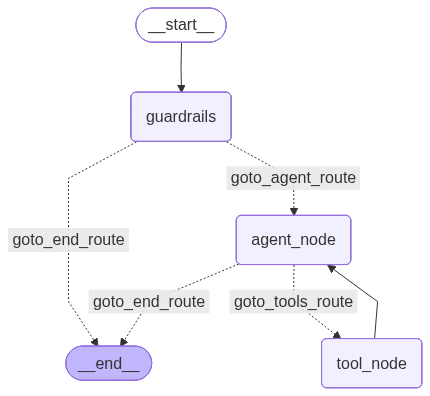

In [ ]:
agent

---

## 🧪 Testing the Healthcare Assistant Agent

Now we'll test our agent with various healthcare queries to validate its capabilities.

### Test Categories

1. **Symptom queries** → Should use web search
2. **Doctor recommendations** → Should use doctor database
3. **Combined queries** → Should use both tools
4. **Out-of-scope queries** → Should be blocked by guardrails
5. **Follow-up questions** → Should maintain context

### Execution Wrapper Utility

We'll use a helper function to:
- Stream agent execution in real-time
- Display formatted final response
- Support multi-user sessions with `thread_id`

### Test Agent on Sample Queries

First, let's download the agent utilities for formatted output:

In [ ]:
!gdown 1dSyjcjlFoZpYEqv4P9Oi0-kU2gIoolMB

Downloading...
From (original): https://drive.google.com/uc?id=1dSyjcjlFoZpYEqv4P9Oi0-kU2gIoolMB
From (redirected): https://drive.google.com/uc?id=1dSyjcjlFoZpYEqv4P9Oi0-kU2gIoolMB&confirm=t&uuid=550f30b0-4dec-4d41-801b-a513b8ea3aa0
To: /content/agent_utils.py
100% 6.45k/6.45k [00:00<00:00, 14.8MB/s]


### Execution Wrapper Function

This utility function manages agent execution with:

**Key Features:**
- **Streaming** — Shows intermediate steps in real-time
- **Session management** — Each user gets isolated conversation history
- **Formatted output** — Displays final response as Markdown
- **Verbose mode** — Optional detailed logging of each step

**Parameters:**
- `agent` — The compiled LangGraph agent
- `prompt` — User's query
- `user_session_id` — Unique thread ID for conversation memory
- `verbose` — Show all intermediate messages (default: False)

**How it works:**
1. Wraps user prompt in `HumanMessage`
2. Streams agent execution with `thread_id` for memory
3. Displays each event as it happens
4. Renders final response as formatted Markdown

In [ ]:
from IPython.display import display, Markdown
from agent_utils import format_message
from langchain_core.messages import HumanMessage

# Utility function to call the agent and stream its step-by-step reasoning for a specific user
def call_conversational_agent(agent, prompt, user_session_id, verbose=False):
    # Stream the agent's execution using the given prompt and session ID for memory tracking
    events = agent.stream(
        {"messages": [HumanMessage(content=prompt)]},   # User input prompt
        {"configurable": {"thread_id": user_session_id}},      # Thread ID for session-based memory (multi-user support)
        stream_mode="values"                                   # Stream messages as the agent processes them
    )

    print('Running Agent. Please wait...')

    # Iterate through each step of the streamed agent output
    for event in events:
        # If verbose mode is enabled, print each intermediate message
        if verbose:
            format_message(event["messages"][-1])

    # Display the final response from the agent as Markdown
    print('\n\nFinal Response:\n')
    if event["messages"][-1].text:
        display(Markdown(event["messages"][-1].text))
    else:
        print(event["messages"][-1].content)

    # Return the overall event messages for optional downstream use
    return event["messages"]

print("✓ Execution wrapper loaded")

✓ Execution wrapper loaded


### What This Does

The execution wrapper:

1. **Creates a user session** with a unique `thread_id` (e.g., `user001`)
2. **Streams the agent's execution** step-by-step
3. **Displays the final response** in a formatted way
4. **Maintains conversation history** across multiple turns

**Multi-User Support:**
```python
# User 1's conversation
call_conversational_agent(agent, "Tell me about diabetes", "user001")

# User 2's conversation (completely isolated)
call_conversational_agent(agent, "I have a headache", "user002")

# User 1's follow-up (remembers previous context)
call_conversational_agent(agent, "What are the symptoms?", "user001")
```

Each `thread_id` maintains its own isolated conversation history in the `MemorySaver` checkpointer.

---

### Test Case 1: Symptom Query with Follow-up

**Scenario:** User asks an out of scope query then asks a query about diabetes treatments, then requests a doctor recommendation.

**Expected Behavior:**
1. First query → Checks out of scope query to see if guardrail works
2. Second query → Uses `search_web` to find current information
3. Third query → Uses `recommend_doctor` based on previous context
4. Agent maintains conversational context ("the same" refers to diabetes)

In [ ]:
uid = 'user001'
query = "Tell me what is AI?"

output = call_conversational_agent(agent, query, uid, verbose=True)

Running Agent. Please wait...


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Tell me what is AI?                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── 🤖 Assistant ──────────────────────────────────────────────────╮
│ 🚫 **Out of Scope**                                                                                             │
│                                                                                                                 │
│ Sorry, I can only assist with medical or healthcare-related queries. Please ask a question within the           │
│ healthcare domain.                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



Final Response:



🚫 **Out of Scope**

Sorry, I can only assist with medical or healthcare-related queries. Please ask a question within the healthcare domain.

In [ ]:
query = "Tell me latest and best methods for diabetes management"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- TOKEN USAGE -------------------------
Token count (input context): 704
Token count (response): 23
------------------------- TOKEN USAGE -------------------------
🔍 Searching web for: latest and best methods for diabetes management 2025
✓ Found 5 results
------------------------- TOKEN USAGE -------------------------
Token count (input context): 45876
Token count (response): 734
------------------------- TOKEN USAGE -------------------------


Final Response:



The latest and best methods for diabetes management in 2025 are comprehensively outlined in the 2025 American Diabetes Association (ADA) Standards of Medical Care in Diabetes. Key updates and recommendations include:

1. Expanded use of Continuous Glucose Monitoring (CGM):
   - CGM is now strongly recommended for a broader population, including individuals with type 2 diabetes (T2DM) not on insulin.
   - Integration of CGM with automated insulin delivery systems (closed-loop systems) for personalized insulin management.

2. Pharmacological Advances:
   - Greater use of combination therapies early in T2DM.
   - Broadened use of glucagon-like peptide-1 receptor agonists (GLP-1 RAs) for weight loss, kidney protection, cardiovascular benefits, and treatment of metabolic dysfunction-associated steatotic liver disease (MASLD).
   - Introduction of dual receptor agonists (GIP and GLP-1) for T2DM and obesity.
   - Sodium-glucose cotransporter 2 (SGLT2) inhibitors remain first-line for heart failure in diabetes, with GLP-1 RAs as complementary agents.
   - New drugs like resmetirom (thyroid hormone receptor-β agonist) for MASLD with fibrosis.

3. Lifestyle and Comprehensive Care:
   - Emphasis on personalized, culturally tailored diabetes self-management education and support (DSMES).
   - Promotion of high-quality, sustainable eating patterns such as plant-based and Mediterranean diets.
   - Encouragement of resistance training combined with aerobic exercise.
   - Recognition of sleep health as a critical factor in diabetes management.
   - Avoidance of recreational cannabis due to risks like cannabis hyperemesis syndrome.

4. Screening and Management of Comorbidities:
   - Targeted screening for heart failure in symptomatic T2DM patients.
   - Annual assessment of kidney function and albuminuria with use of SGLT2 inhibitors and mineralocorticoid receptor antagonists for renal protection.
   - Updated cardiovascular risk management including use of GLP-1 RAs and SGLT2 inhibitors.

5. Technological Integration:
   - Increased use of digital tools, mobile apps, and virtual platforms to enhance patient engagement.
   - Use of automated insulin delivery systems and closed-loop technology.

6. Emerging Research and Equity:
   - Early intervention with SGLT2 inhibitors to slow chronic kidney disease progression.
   - Emphasis on equitable access to diabetes care and technology globally.

For detailed guidelines, you can refer to the full 2025 ADA Standards of Care document here:
https://www.explorationpub.com/Journals/eemd/Article/101428

Additional resources and updates are available from the American Diabetes Association:
https://diabetes.org/newsroom/press-releases/american-diabetes-association-releases-standards-care-diabetes-2025

These updates reflect a shift towards personalized, technology-integrated, and comprehensive care to improve outcomes for people with diabetes.

If you need, I can also recommend diabetes specialists for consultation. Would you like me to do that?

Sources:
- Tiwari D, Loh WJ, Aw TC. Updates from the 2025 American Diabetes Association guidelines on standards of medical care in diabetes. Explor Endocr Metab Dis. 2025;2:101428. https://doi.org/10.37349/eemd.2025.101428
- American Diabetes Association. Releases Standards of Care in Diabetes—2025. https://diabetes.org/newsroom/press-releases/american-diabetes-association-releases-standards-care-diabetes-2025

In [ ]:
query = "Please recommend a right doctor for the same"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- TOKEN USAGE -------------------------
Token count (input context): 46625
Token count (response): 33
------------------------- TOKEN USAGE -------------------------
🏥 Finding doctors for: diabetes management, type 2 diabetes, glucose monitoring, pharmacological therapy, lifestyle management
📊 Retrieved 3 doctor profiles
🤖 Generating recommendations...
✓ Recommendations generated
------------------------- TOKEN USAGE -------------------------
Token count (input context): 46745
Token count (response): 108
------------------------- TOKEN USAGE -------------------------


Final Response:



I recommend consulting with the following specialist for diabetes management:

Name: Dr. Janet Dyne
Specialization: Endocrinology
Location: City Health Clinic
Available Timings: 10:00 AM - 1:00 PM
Contact Email: janet.dyne@healthclinic.com

You can book an appointment with Dr. Janet Dyne via email at the provided contact. She specializes in endocrinology and is well-suited to help with diabetes management including glucose monitoring, pharmacological therapy, and lifestyle interventions.

**Analysis:**
- ✅ Agent correctly interprets "the same" as referring to diabetes
- ✅ Uses conversation history to provide contextual recommendations
- ✅ Demonstrates successful memory integration

---

### Test Case 2: Out-of-Scope Query

**Scenario:** User asks about a non-healthcare topic.

**Expected Behavior:**
- Guardrail node classifies query as BLOCK
- Returns polite rejection message
- Does not invoke agent or tools

In [ ]:
query = "What is Agentic AI?"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...


Final Response:



🚫 **Out of Scope**

Sorry, I can only assist with medical or healthcare-related queries. Please ask a question within the healthcare domain.

**Analysis:**
- ✅ Guardrail successfully blocks non-healthcare query
- ✅ Provides clear guidance to user
- ✅ Prevents unnecessary tool usage and token consumption

---

### Test Case 3: Mental Health Query

**Scenario:** User asks about managing panic attacks.

**Expected Behavior:**
- Uses `search_web` for evidence-based coping strategies
- Provides empathetic, helpful response
- May recommend consulting a mental health professional

In [ ]:
query = "How to prevent panic attacks"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- TOKEN USAGE -------------------------
Token count (input context): 46908
Token count (response): 24
------------------------- TOKEN USAGE -------------------------
🔍 Searching web for: how to prevent panic attacks latest medical advice 2025
✓ Found 5 results
------------------------- TOKEN USAGE -------------------------
Token count (input context): 93019
Token count (response): 379
------------------------- TOKEN USAGE -------------------------


Final Response:



To prevent panic attacks, here are some of the latest medically advised methods in 2025:

1. Practice muscle relaxation techniques such as progressive muscle relaxation to reduce muscle tension.
2. Use deep breathing exercises like diaphragmatic breathing or the 4-7-8 breathing technique to calm the nervous system.
3. Employ grounding techniques such as the 5-4-3-2-1 method to focus on the present and reduce overwhelming feelings.
4. Repeat positive mantras to reassure yourself during moments of anxiety.
5. Engage in light exercise or walking regularly to release endorphins and improve mood.
6. Take prescribed medications if recommended by a doctor, including SSRIs or short-term benzodiazepines.
7. Learn and avoid personal triggers that may provoke panic attacks.
8. Maintain a healthy lifestyle with good sleep hygiene, balanced diet, hydration, and avoidance of caffeine, alcohol, and nicotine.
9. Seek cognitive behavioral therapy (CBT) or exposure therapy to build coping skills and reduce anxiety.
10. Build a support system and communicate with trusted individuals about your condition.

If panic attacks are frequent or severe, professional help from a mental health specialist is important.

For more detailed information, you can visit:
https://www.medicalnewstoday.com/articles/321510

If you want, I can also recommend a mental health specialist for consultation. Would you like that?

Sources:
- Medical News Today, "How to stop a panic attack: 11 effective methods," updated April 29, 2025. https://www.medicalnewstoday.com/articles/321510
- Psychology Today, "New Research Reviews Treatments for Panic Disorder," May 21, 2025. https://www.psychologytoday.com/ca/blog/from-lab-to-real-world/202505/new-research-reviews-treatments-for-panic-disorder

---

### Test Case 4: General Health Question

**Scenario:** User asks about maintaining eye health.

**Expected Behavior:**
- Uses `search_web` for evidence-based recommendations
- Provides comprehensive information about eye care

In [ ]:
query = "Tell me the best methods to keep my eyesight sharp"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- TOKEN USAGE -------------------------
Token count (input context): 93415
Token count (response): 22
------------------------- TOKEN USAGE -------------------------
🔍 Searching web for: best methods to keep eyesight sharp 2025
✓ Found 5 results
------------------------- TOKEN USAGE -------------------------
Token count (input context): 109484
Token count (response): 662
------------------------- TOKEN USAGE -------------------------


Final Response:



To keep your eyesight sharp and maintain good eye health in 2025, here are the best methods recommended by eye care experts:

1. Wear Sunglasses: Use sunglasses that block 99–100% of UVA and UVB rays to protect your eyes from harmful ultraviolet light, which can cause cataracts and macular degeneration.

2. Use Safety Eyewear: If exposed to hazardous materials or during sports, wear protective glasses or goggles to prevent eye injuries.

3. Eat a Nutrient-Rich Diet: Include foods rich in omega-3 fatty acids, lutein, zinc, and vitamins C and E such as leafy greens, oily fish, nuts, seeds, and citrus fruits to reduce the risk of eye diseases.

4. Quit Smoking: Smoking increases the risk of cataracts, optic nerve damage, and macular degeneration.

5. Take Breaks from Screens: Follow the 20-20-20 rule—every 20 minutes, look at something 20 feet away for 20 seconds—to reduce digital eye strain.

6. Schedule Regular Eye Exams: Annual comprehensive eye exams help detect conditions like glaucoma, cataracts, and macular degeneration early.

7. Get Quality Sleep: Adequate sleep allows your eyes to rest, rehydrate, and repair, preventing dry eyes and irritation.

8. Practice Good Hygiene: Wash hands before touching eyes or handling contact lenses, remove makeup thoroughly, and clean contact lenses properly.

9. Maintain Proper Screen Habits: Adjust screen brightness, use anti-glare coatings, and blink often to prevent eye strain.

10. Stay Hydrated: Drink 6-8 cups of water daily to keep eyes lubricated.

11. Consider Vision-Boosting Foods: Carrots, spinach, fatty fish, and citrus fruits support eye health.

12. Protect Eyes from UV Damage: Wear wide-brimmed hats and polarized lenses for extra protection outdoors.

13. Manage Dry Eye Syndrome: Use lubricating eye drops and warm compresses if needed.

14. Incorporate Eye Exercises: Simple exercises can strengthen eye muscles and reduce fatigue.

For more detailed guidance, you can visit:
- https://eyepiceyecare.com/how-to-keep-your-eyes-healthy-ultimate-guide-2025/
- https://filutowskieye.com/your-2025-eye-care-checklist-healthy-habits-for-a-new-year/
- https://nassaufultonvisioncenter.com/eye-care-routines-to-prioritize-in-2025/

If you want, I can also recommend an eye specialist for consultation. Would you like that?

Sources:
- Eyepic Eye Care, "How to Keep Your Eyes Healthy – Ultimate Guide (2025)" https://eyepiceyecare.com/how-to-keep-your-eyes-healthy-ultimate-guide-2025/
- Filutowski Eye Institute, "Your 2025 Eye Care Checklist: Healthy Vision Starts Now" https://filutowskieye.com/your-2025-eye-care-checklist-healthy-habits-for-a-new-year/
- Nassau Fulton Vision Center, "Eye Care Routines to Prioritize in 2025" https://nassaufultonvisioncenter.com/eye-care-routines-to-prioritize-in-2025/

---

### 🚨 The Context Window Problem

If you continue running more queries with the same `thread_id`, you'll encounter a critical issue:

**Maximum Context Window Exceeded Error**

**What happens:**
1. Each user query adds ~500-1000 tokens to history
2. Each tool response adds ~5,000-50,000 tokens (especially web search)
3. After ~5-10 interactions, total context can potentially exceeds LLM's limit
4. Agent crashes with context window error

**Why this is a problem:**
- ❌ Web search results consume massive token budgets
- ❌ No way to have long-running conversations
- ❌ Poor user experience (conversation unexpectedly ends)

**Current memory growth:**
```
Turn 1:  5,000 tokens (initial query + web search)
Turn 2: 10,000 tokens (previous + new query + results)
Turn 3: 25,000 tokens
Turn 4: 50,000 tokens
Turn 5: 85,000 tokens
Turn 6+: 120,000+ tokens
Over time: ❌ ERROR: Context limit exceeded
```

This is exactly what **Part II** solves with **Memory Context Engineering**.

---

---

---

# Part II: Optimize your Health Assistant Agentic AI System with Memory Context Engineering

---

---

## Optimize your Health Assistant Agentic AI System with Memory Context Engineering

In Part I, we built a functional healthcare assistant but encountered a critical limitation: **context window overflow**.

### The Problem

**Uncontrolled Memory Growth:**
- Web search results: 10,000-50,000 tokens per call
- Conversation history: Grows linearly with each turn
- LLM context limit: 120,000 tokens (GPT-4.1-mini)
- **Result:** Agent crashes after 5-10 interactions

### The Solution: Context Engineering

We implement **two optimization strategies**:

1. **Context Trimming** — Keep only the most recent N messages
2. **Tool Response Summarization** — Compress large web search results

**Combined Result:**
- 96% reduction in memory usage
- Unlimited conversation length
- Maintains conversational quality

### New Architecture

```
Old Flow (Part I):
START → Guardrails → Agent → Tools → Agent → END

New Flow (Part II):
START → Context Trimmer → Guardrails → Agent → Tools (with Summarization) → Context Trimmer → ...
```

**Key Changes:**
1. **Context Trimmer Node** — Runs before every agent invocation
2. **Tool Summarization** — Compresses web search results from 50K → 10K tokens
3. **Feedback Loop** — Tools route back to trimmer (not agent)

Let's implement these optimizations.

---

## 🔧 Implementation: Optimized Agent with Memory Engineering

### Strategy Overview

| Component | Optimization | Impact |
|-----------|--------------|--------|
| **Message History** | Keep last 12 messages (~3 interactions) | -80% token usage |
| **Web Search Results** | Summarize 50K tokens → 10K words | -60% token usage |
| **Combined** | Both strategies together | **-96% total** |

### Why These Numbers?

**12 messages = ~3 complete interactions:**
```
Interaction 1: HumanMessage + AIMessage + ToolMessage + AIMessage (4 messages)
Interaction 2: HumanMessage + AIMessage + ToolMessage + AIMessage (4 messages)
Interaction 3: HumanMessage + AIMessage + ToolMessage + AIMessage (4 messages)
Total: 12 messages
```

This provides enough context for:
- ✅ Understanding current conversation thread
- ✅ Maintaining references ("the same", "that condition")
- ✅ Avoiding repetitive information
- ❌ Older context beyond 3 turns is trimmed

**10K word summaries:**
- Retains essential medical information
- Removes redundant content from multiple sources
- Preserves source citations for credibility

### Create a mapping of `{tool name : actual tool implementation}`

We create a **tool name lookup dictionary** for the custom tools node.

**Why this is needed:**
- LLM returns tool calls with just the tool name as a string
- We need to map name → actual tool function to execute it
- Enables custom tool handling logic (e.g., selective summarization)

```python
{
  "search_web": <function search_web>,
  "recommend_doctor": <function recommend_doctor>
}
```

In [ ]:
tools_by_name = {tool.name: tool for tool in tools}

print(f"✓ Tool mapping created: {list(tools_by_name.keys())}")

✓ Tool mapping created: ['search_web', 'recommend_doctor']


In [ ]:
tools_by_name

{'search_web': StructuredTool(name='search_web', description='Search the web for current health information and evidence-based content.\n\n    Use this tool when:\n    - User asks about general health topics, treatments, or medical conditions\n    - Current or recent information is needed (research from 2025)\n    - Evidence-based health guidelines are required\n\n    Args:\n        query (str): The search query string. Should describe the healthcare\n                    topic or information you want to find.\n\n    Returns:\n        list: A list of up to 3 formatted strings, each containing:\n              - Title of the search result\n              - Content extracted from the page\n              - Source URL\n              Returns empty list if search fails.\n\n    Example:\n        >>> results = search_web("diabetes type 2 symptoms")\n        >>> print(results[0][:100])\n        "## Title\nDiabetes Symptoms - Mayo Clinic..."', args_schema=<class 'langchain_core.utils.pydantic.searc

### Define Agent Node Functions & Graph

### Defining Agent State Schema & Guardrails Node for Healthcare Scope Validation (Same as Part I)

#### Agent State Schema

We use `messages` as a list to store any agent messages throughout its execution lifecycle and `guardrail_decision` to store if the user query is ALLOW(ed) or BLOCK(ed).

**Agent State:**
```python
class State(TypedDict):
    messages: Annotated[list, add_messages]
    guardrail_decision: str  # "ALLOW" | "BLOCK"

```

#### Guardrails

**Guardrails** are safety mechanisms that validate whether a query is within the agent's intended scope.

**Why guardrails matter:**
- Prevents misuse (e.g., asking about non-healthcare topics)
- Focuses agent capabilities on intended domain
- Provides clear feedback when queries are out of scope

**How it works:**
1. Extract the latest user message from state
2. Ask a classifier LLM: "Is this healthcare-related?"
3. Use **structured output** (Pydantic model) to ensure ALLOW/BLOCK format
4. Route based on decision:
   - **ALLOW** → Continue to agent
   - **BLOCK** → Return rejection message and end

**Pydantic Schema:**
```python
class HealthcareScopeDecision(BaseModel):
    decision: Literal["ALLOW", "BLOCK"]
```

This forces the LLM to return only "ALLOW" or "BLOCK", making routing deterministic.

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field
from typing import Literal, Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
import warnings
warnings.filterwarnings("ignore")


# create agent state schema
class State(TypedDict):
    messages: Annotated[list, add_messages]
    guardrail_decision: str  # "ALLOW" | "BLOCK"

# create guardrails reponse schema
class HealthcareScopeDecision(BaseModel):
    decision: Literal["ALLOW", "BLOCK"] = Field(
        description="ALLOW if the query is healthcare related, otherwise BLOCK"
    )

# function to retrieve the latest user prompt
def get_latest_human_message(messages):
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            return msg
    return None

GUARDRAIL_PROMPT = """
You are a classifier.

Decide whether the user query is related to:
- healthcare
- medical symptoms
- diseases
- treatments
- medicines
- doctors
- hospitals
- diagnostics
- medical research

If it IS related to healthcare, respond with:
ALLOW

If it is NOT related to healthcare, respond with:
BLOCK
"""

def guardrail_node(state: State) -> State:
    current_agent_messages = state["messages"]

    # always get the most recent user prompt to run guardrails on
    latest_human = get_latest_human_message(current_agent_messages)
    if latest_human is None:
        return state  # nothing to evaluate

    user_query = latest_human.content.strip()

    classifier_messages = [
        SystemMessage(content=GUARDRAIL_PROMPT),
        HumanMessage(content=user_query),
    ]

    # classify user prompt as to be ALLOWed or BLOCKed
    content_scope = llm_with_tools.with_structured_output(
        HealthcareScopeDecision
    ).invoke(classifier_messages)


    if content_scope.decision == "BLOCK":

        blocked_response = [
            AIMessage(
                content=(
                    "🚫 **Out of Scope**\n\n"
                    "Sorry, I can only assist with medical or "
                    "healthcare-related queries. Please ask a question "
                    "within the healthcare domain."
                )
            )
        ]

        return {
            "guardrail_decision": "BLOCK",
            "messages": blocked_response
        }

    # Allowed → pass state unchanged
    return {
        "messages" : current_agent_messages,
        "guardrail_decision": "ALLOW"
    }

# routing function to route agent execution flow after seeing guardrail decision
def guardrail_conditional_routing(state: State):
    decision = state.get("guardrail_decision")

    if decision == "BLOCK":
        return "goto_end_route"

    return "goto_agent_route"

### Defining the Context Trimmer Node

This node implements **intelligent message history trimming**.

**How it works:**

1. **Count current messages** in state
2. **Check threshold** — Only trim if > 12 messages which is roughly 3 user-agent interactions (considering 1 user-agent interaction is: user prompt  → tool call request  → tool call response  → LLM response, which is roughly 4 messages)
3. **Use `trim_messages` utility** with these parameters:
   - `max_tokens=12` — Keep last 12 messages (using count, not actual tokens)
   - `strategy="last"` — Retain most recent messages
   - `token_counter=len` — Count by number of messages (not token count)
   - `allow_partial=False` — Keep complete messages only
   - `start_on="human"` — Ensure trimmed history starts with user message
4. **Return state update** using `RemoveMessage` API

**State Update Pattern:**
```python
{
  "messages": [
    RemoveMessage(id=REMOVE_ALL_MESSAGES),  # Clear all old messages
    ...trimmed_messages                      # Add back last 12 messages
  ]
}
```

**Why this approach?**
- ✅ Removes messages from state completely (saves memory)
- ✅ Preserves message ordering and structure
- ✅ Ensures conversational coherence (starts with human message)
- ✅ Only trims when necessary (conditional execution)

**Note:** In real-world scenarios you can increase this to include longer history windows e.g 60+ messages (20+ user-agent interactions)

In [ ]:
from langchain_core.messages import trim_messages
from langgraph.graph.message import RemoveMessage, REMOVE_ALL_MESSAGES
# Memory Context Trimmer node function
# Takes the memory history of agent messages and retains the most recent K messages
def context_trimmer_node(state: State) -> State:
    """
    Conditionally trims conversation history to maintain optimal context window.
    Only performs trimming when message count exceeds the threshold.
    """
    print('-'*25, 'Context Trimmer Node', '-'*25)

    current_agent_state = state["messages"]
    message_count = len(current_agent_state)

    print(f'Current Messages Count: {message_count}')

    # Define the threshold for trimming
    MAX_MESSAGES = 12

    # Only trim if we've exceeded the threshold
    if message_count > MAX_MESSAGES:
        print(f'⚠️  Message count ({message_count}) exceeds threshold ({MAX_MESSAGES})')
        print(f'Trimming to retain last {MAX_MESSAGES} messages...')

        trimmed_state = trim_messages(
            current_agent_state,
            max_tokens=MAX_MESSAGES,  # Keep last 12 messages (approx 3 interactions, 1 interaction is user query, tool call, tool response and llm response)
            strategy="last",           # Retain the most recent messages
            token_counter=len,         # Use number of messages based counting
            allow_partial=False,        # Keep complete messages only
            start_on="human",      # Start at human message
        )

        trimmed_count = len(trimmed_state)
        removed_count = message_count - trimmed_count

        print(f'✂️  Trimmed: {removed_count} messages removed, {trimmed_count} messages retained')
        print('-'*75)

        # Return state with old messages removed and trimmed messages added
        return {"messages": [RemoveMessage(id=REMOVE_ALL_MESSAGES)] + trimmed_state}

    else:
        print(f'✅ No trimming needed (threshold: {MAX_MESSAGES} messages)')
        print('-'*75)

        # Return empty dict - no state update needed
        return {}

print("✓ Context trimmer node defined")

✓ Context trimmer node defined


### Agent Node + Tools Node: LLM Reasoning with Tools (Same as Part I)

The agent node function implements the **core agent logic**:

**What it does:**
1. Takes current state (conversation messages)
2. Prepends system prompt with instructions
3. Invokes LLM with tools bound
4. Returns LLM response (either text answer or tool call)

**LLM Response Types:**
- **Text response** — Direct answer (e.g., "Diabetes is a condition...")
- **Tool call request** — Request to invoke a tool (e.g., `search_web("diabetes symptoms")`)

The tools node function uses the built-in `ToolNode` to execute tool calls based on requests

The graph's conditional routing will decide next steps based on whether tool calls are present.

In [ ]:
# Create the node function that handles reasoning and planning using the LLM
def tool_calling_llm(state: State) -> State:
    # get agent state and then get next step (response) from llm
    current_agent_state = state["messages"]
    state_with_instructions = [AGENT_SYS_PROMPT] + current_agent_state
    llm_response = [llm_with_tools.invoke(state_with_instructions)]

    token_usage = llm_response[0].usage_metadata
    print('-'*25, 'TOKEN USAGE', '-'*25)
    print("Token count (input context):", token_usage['input_tokens'])
    print("Token count (response):", token_usage['output_tokens'])
    print('-'*25, 'TOKEN USAGE', '-'*25)

    # Return the updated agent state for message queue
    return {"messages": llm_response}

# create node function for tools
tool_node = ToolNode(tools=tools)

# Helps in conditional routing to conditional edges
def agent_conditional_routing(state: State) -> Literal["tools", "__end__"]:
    # Checks if a tool or tools need to be called or LLM can generate output for next step
    last_state_message = state["messages"][-1]
    if last_state_message.tool_calls and len(last_state_message.tool_calls) > 0:
        return "goto_tools_route"
    return "goto_end_route"

### Agent System Prompt (Same as Part I)

We define a clear, instruction-focused system prompt for the agent.

In [ ]:
from langchain_core.messages import SystemMessage

AGENT_PROMPT_TXT = """You are an agent designed to act as an expert in researching on medical symptoms
and also recommend relevant doctors for booking appointments. The current year is 2025.

Given an input user query call relevant tools and give the most appropriate response.
Follow some of these guidelines to help you make more informed decisions:
  - If the user's query specifies recommending a doctor only then recommend an appropriate doctor
  - If the user is researching on aspects around healthcare use web search
  - Recommend doctors based on information from user queries in case exact symptoms are not mentioned
  - Response should include cited source links, Publication Dates if available
  - If recommending doctors then show detailed information in a nice structured way and recommend them to book an appointment via email
  - If user's query is a follow-up query, refer to the entire agent historical messages to answer with the right context
"""

AGENT_SYS_PROMPT = SystemMessage(content=AGENT_PROMPT_TXT)

print("✓ Agent system prompt configured")

✓ Agent system prompt configured


### Custom Tools Node with Summarization

This is the **most critical optimization** — a custom tool execution node that selectively summarizes tool results.

**Strategy:**

```python
if tool_name == "search_web":
    1. Execute tool → Get ~500K tokens of web content
    2. Trim to 100K tokens (safety limit)
    Can be increased if summarizing with longer context LLMs.
    We reduced it for the purpose of the demo.
    3. Summarize with LLM → ~10K words (~(2K - 8K) tokens)
    4. Return summarized content
else:  # recommend_doctor or other tools
    Execute normally (no summarization)
```

**Why selective summarization?**
- `search_web` returns massive content (5 web pages × ~100K tokens each)
- `recommend_doctor` returns small JSON (~500 tokens)
- Only summarize when necessary to avoid degrading quality

**Summarization Prompt:**
```
Create a comprehensive report of approx 10,000 words max
- Retain main aspects and key details
- Keep sources for citations
- Preserve medical accuracy
```

**Token Flow:**
```
Web Search Results: 500,000 tokens
         ↓ trim_messages(max_tokens=100K)
Trimmed Results: 100,000 tokens
         ↓ LLM summarization
Summarized Results: ~10,000 words ≈ 2,000 - 8,000 tokens
         ↓
Return as ToolMessage (tool response) back to agent
```

In [ ]:
from langchain_core.messages import trim_messages
from langchain_core.messages import ToolMessage

TOOL_SUMMARIZER_PROMPT = """Given the following context information,
summarize it ensuring to retain all relevant / essential information.
Your goal is simply to reduce the size of the context to a more manageable size.
Follow these exact rules for summarization:
- Create a comprehensive report of approx 10000 words max
- Retain the main aspects of the documents being summarized including key details, facts and context
- Keep the sources of the articles or papers if available so they can be refered to when needed
"""
trimmer_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)



# Custom Tools node function
# - trims tool call response to < 150K tokens
# - summarizes tool call response to around ~10K words
def tool_node_with_summarization(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        # call the tool - based on the requested tool call name and arguments
        tool = tools_by_name[tool_call["name"]]

        # summarization of tool results
        if tool_call["name"] == 'search_web':
            print('-'*25, 'Tool Call in Summarization Pipeline', '-'*25)
            tool_results = tool.invoke(tool_call["args"])
            if type(tool_results) == list:
                tool_results = [str(doc) for doc in tool_results]
            else:
                tool_results = [str(tool_results)]
            # trim tool response context to < LLM max context window
            trimmed_tool_results = trim_messages(
                tool_results,
                max_tokens=100000,              # roughly 10% of GPT-4.1-mini (1M window) context window size but you can increase it upto 1M
                strategy="first",                # Retain the top content (which came first)
                token_counter=ChatOpenAI(model="gpt-4.1-mini"),  # Use LLM-based token counting
                allow_partial=True              # Allow partial trimming of messages if needed
            ) # trim_messages always returns results as LangChain Messages
            trimmed_tool_results = '\n\n'.join([msg.content for msg in trimmed_tool_results]) # making sure tool result is a string

            print('-'*25, 'Summarizing Tool Results', '-'*25)
            # Summarize the tool response context further
            # You can handle various types of tool calls in different ways in this node
            summarized_tool_results = trimmer_llm.invoke(
                                            [
                                                SystemMessage(content=TOOL_SUMMARIZER_PROMPT),
                                                HumanMessage(content=trimmed_tool_results)
                                            ]
            )
            # add transformed tool response context as tool message in agent state
            result.append(
                ToolMessage(content=summarized_tool_results.content,
                            tool_call_id=tool_call["id"])
            )
        else:
            print('-'*25, 'Tool Call in Regular Pipeline', '-'*25)
            tool_results = tool.invoke(tool_call["args"])
            tool_results = str(tool_results) # making sure final tool message is always text
            result.append(
                ToolMessage(content=tool_results,
                            tool_call_id=tool_call["id"])
            )

    return {"messages": result}

# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def agent_conditional_routing(state: State):
    # Checks if a tool or tools need to be called or LLM can generate output for next step
    last_state_message = state["messages"][-1]
    if last_state_message.tool_calls and len(last_state_message.tool_calls) > 0:
        return "goto_tools_route"
    return "goto_end_route"

print("✓ Custom tool node with summarization defined")

✓ Custom tool node with summarization defined


### Building the Optimized Agent Graph

Now we assemble the complete optimized architecture.

**Key Differences from Part I:**

| Component | Part I | Part II |
|-----------|--------|----------|
| **First Node** | Guardrails | Context Trimmer |
| **Tools Node** | ToolNode (prebuilt) | Custom with summarization |
| **Feedback Loop** | Tools → Agent | Tools → Context Trimmer |
| **State** | messages + guardrail_decision | messages only |

**Graph Flow:**

```
START
  ↓
Context Trimmer (trim if > 12 messages)
  ↓
Guardrails (ALLOW/BLOCK)
  ↓ (if ALLOW)
Agent (reasoning + tool selection)
  ↓
  ├─→ Tools with Summarization
  │     ↓
  │   Context Trimmer (loop back here, not to agent!)
  │     ↓
  │   Guardrails (re-validate)
  │     ↓
  │   Agent (process summarized results)
  │     ↓
  └─→ END
```

**Why loop back to trimmer?**
- After tools add new messages, check if trimming is needed
- Ensures context never exceeds threshold
- Maintains consistent memory footprint

In [ ]:
# Build the graph
builder = StateGraph(State)

# Add nodes
builder.add_node("context_trimmer", context_trimmer_node)
builder.add_node("guardrails", guardrail_node)
builder.add_node("agent_node", tool_calling_llm)
builder.add_node("tools_node_with_summarizer", tool_node_with_summarization)

# Add edges
builder.add_edge(START, "context_trimmer")
builder.add_edge("context_trimmer", "guardrails")

# Conditional edge for guardrail processing
builder.add_conditional_edges(
    "guardrails",
    guardrail_conditional_routing,
    {
        "goto_agent_route": "agent_node",
        "goto_end_route": END
    }
)

# Conditional edge for agent processing
builder.add_conditional_edges(
    "agent_node",
    agent_conditional_routing, # conditional routing function
    {
        "goto_end_route": END,
        "goto_tools_route": "tools_node_with_summarizer"
    }
)

builder.add_edge("tools_node_with_summarizer", "context_trimmer") # this is the key feedback loop in the agentic system

# Compile Agent Graph with memory
memory = MemorySaver()
agent = builder.compile(checkpointer=memory)

print("✓ Optimized agent graph compiled successfully")
print("✓ Context engineering enabled")

✓ Optimized agent graph compiled successfully
✓ Context engineering enabled


**Visualize the Optimized Graph:**

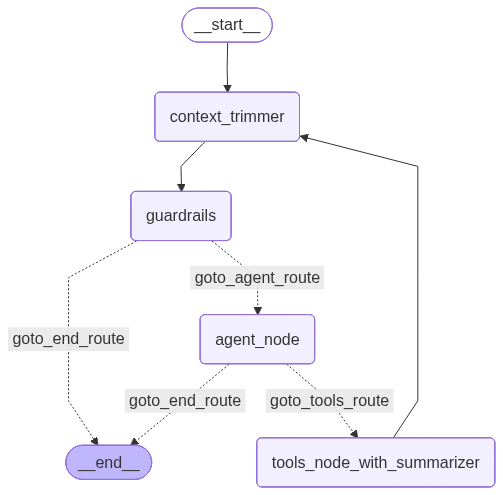

In [ ]:
agent

---

## 🧪 Testing the Optimized Agent

Now let's test the optimized agent with the same queries to validate the improvements.

**What to observe:**
1. ✅ Conversation works correctly (same quality as Part I)
2. ✅ Context trimmer logs show when trimming occurs
3. ✅ Tool summarization logs for web search
4. ✅ Memory stays bounded (can run unlimited queries)

**Expected console output patterns:**
```
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 8
✅ No trimming needed (threshold: 12 messages)

🛡️ Guardrail Decision: ALLOW

🤖 Agent response type: Tool Call

------------------------- Tool Call in Summarization Pipeline -------------------------
🔍 Searching web for: diabetes symptoms
------------------------- Summarizing Tool Results -------------------------
```

### Test Agent on Sample Queries

### Test Case 1: Symptom Query with Follow-up (Same as Part I)

In [ ]:
uid = 'user001'
query = "Tell me what is AI?"

output = call_conversational_agent(agent, query, uid, verbose=True)

Running Agent. Please wait...


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Tell me what is AI?                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

------------------------- Context Trimmer Node -------------------------
Current Messages Count: 1
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------


╭───────────────────────────────────────────────── 🤖 Assistant ──────────────────────────────────────────────────╮
│ 🚫 **Out of Scope**                                                                                             │
│                                                                                                                 │
│ Sorry, I can only assist with medical or healthcare-related queries. Please ask a question within the           │
│ healthcare domain.                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



Final Response:



🚫 **Out of Scope**

Sorry, I can only assist with medical or healthcare-related queries. Please ask a question within the healthcare domain.

In [ ]:
query = "Tell me latest and best methods for diabetes management"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 3
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------
------------------------- TOKEN USAGE -------------------------
Token count (input context): 704
Token count (response): 23
------------------------- TOKEN USAGE -------------------------
------------------------- Tool Call in Summarization Pipeline -------------------------
🔍 Searching web for: latest and best methods for diabetes management 2025
✓ Found 5 results
------------------------- Summarizing Tool Results -------------------------
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 5
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------
------------------------- TOKEN USAGE -------------------------
Token count (input 

The latest and best methods for diabetes management in 2025 are comprehensively outlined in the 2025 American Diabetes Association (ADA) Standards of Medical Care in Diabetes. Key highlights include:

1. Early and precise diagnosis:
   - Expanded antibody-based screening for presymptomatic Type 1 Diabetes in high-risk individuals.
   - Use of HbA1c as a primary diagnostic test.

2. Pharmacological advances:
   - Early combination therapy for Type 2 Diabetes with GLP-1 receptor agonists (GLP-1 RAs) and dual GIP-GLP-1 receptor agonists (e.g., tirzepatide).
   - SGLT2 inhibitors recommended for heart failure and chronic kidney disease protection regardless of glycemic control.
   - New drugs and combinations for metabolic-associated steatohepatitis (MASH).

3. Lifestyle and comprehensive care:
   - Personalized, culturally tailored diabetes self-management education and support (DSMES).
   - Emphasis on sustainable eating patterns (plant-based, Mediterranean), adequate hydration, and moderation of non-nutritive sweeteners.
   - Combined aerobic and resistance exercise.
   - Sleep health (6–9 hours/night) and mental health screening.
   - Strong recommendation against recreational cannabis use due to risks.

4. Technology integration:
   - Broader use of continuous glucose monitoring (CGM) including in non-insulin treated Type 2 Diabetes.
   - Use of automated insulin delivery (AID) systems and digital tools for personalized care.

5. Special populations:
   - Updated pregnancy care with AID systems and adjusted folic acid dosing.
   - Older adults benefit from CGM to reduce hypoglycemia risk.
   - Weight management includes ongoing pharmacotherapy and malnutrition screening.

6. Addressing health disparities:
   - Focus on equitable access to medications, technology, and education globally.

These guidelines emphasize individualized, patient-centered care with a focus on early intervention, advanced pharmacotherapy, lifestyle modification, and technology use to improve outcomes and reduce complications.

For detailed information, you can refer to the following sources:
- Exploration of Endocrine and Metabolic Diseases, 2025: https://www.explorationpub.com/Journals/eemd/Article/101428
- diaTribe, January 2025: https://diatribe.org/diabetes-management/your-guide-2025-ada-standards-care
- National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK), March 2025: https://www.niddk.nih.gov/health-information/professionals/diabetes-discoveries-practice/changes-standards-care-diabetes2025
- American Diabetes Association Press Release, December 2024: https://diabetes.org/newsroom/press-releases/american-diabetes-association-releases-standards-care-diabetes-2025
- ADA Meeting News, June 2025: https://www.adameetingnews.org/standards-of-care-in-diabetes-2025-brings-updates-to-practice/

If you want, I can also recommend diabetes specialists for consultation. Would you like me to do that?

In [ ]:
query = "Please recommend a right doctor for the same"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 7
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------
------------------------- TOKEN USAGE -------------------------
Token count (input context): 4057
Token count (response): 18
------------------------- TOKEN USAGE -------------------------
------------------------- Tool Call in Regular Pipeline -------------------------
🏥 Finding doctors for: diabetes management
📊 Retrieved 3 doctor profiles
🤖 Generating recommendations...
✓ Recommendations generated
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 9
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------
------------------------- TOKEN USAGE -------------------------
Token count (input context): 4162
Token count (response): 90

I recommend consulting with the following specialist for diabetes management:

Name: Dr. Janet Dyne  
Specialization: Endocrinology  
Location: City Health Clinic  
Available Timings: 10:00 AM - 1:00 PM  
Contact: janet.dyne@healthclinic.com  

You can book an appointment by reaching out via the provided email. If you need assistance with booking or more doctor options, please let me know!

**Observation:**
- ✅ Context maintained ("the same" correctly interpreted)
- ✅ Web search results were summarized
- ✅ Message count stays low

---

### Test Case 2: Out-of-Scope Query

In [ ]:
query = "How to create an AI agent"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 11
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------


Final Response:



🚫 **Out of Scope**

Sorry, I can only assist with medical or healthcare-related queries. Please ask a question within the healthcare domain.

**Observation:**
- ✅ Guardrail correctly blocks non-healthcare query
- ✅ No tool calls made (efficient)

---

### Test Case 3: Mental Health Query

In [ ]:
query = "How to prevent panic attacks"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 13
⚠️  Message count (13) exceeds threshold (12)
Trimming to retain last 12 messages...
✂️  Trimmed: 2 messages removed, 11 messages retained
---------------------------------------------------------------------------
------------------------- TOKEN USAGE -------------------------
Token count (input context): 4264
Token count (response): 23
------------------------- TOKEN USAGE -------------------------
------------------------- Tool Call in Summarization Pipeline -------------------------
🔍 Searching web for: how to prevent panic attacks latest methods 2025
✓ Found 5 results
------------------------- Summarizing Tool Results -------------------------
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 13
⚠️  Message count (13) exceeds threshold (12)
Trimming to retain last 12 messages...
✂️  Trimmed: 4 messages remo

To prevent panic attacks, here are some of the latest and effective methods recommended in 2025:

1. Immediate Coping Techniques:
   - Practice slow, deep breathing exercises (e.g., 4-4-4-4 count) to counteract hyperventilation.
   - Use grounding techniques like the 5-4-3-2-1 method to focus on sensory input.
   - Employ positive self-talk such as "This is temporary" to reduce fear.
   - Try progressive muscle relaxation and visualization of peaceful places.
   - Use temperature-based methods like holding ice or splashing cold water.
   - Distract yourself by counting backwards.

2. Avoid:
   - Fighting the panic or trying to force it away.
   - Immediate escape from the situation, which can reinforce fear.
   - Catastrophizing thoughts and stimulants like caffeine during an attack.

3. Long-Term Prevention:
   - Recognize early warning signs to intervene early.
   - Engage in Cognitive Behavioral Therapy (CBT), the most effective therapy.
   - Consider medication like SSRIs or SNRIs under medical supervision.
   - Maintain a healthy lifestyle with regular exercise, balanced diet, and good sleep.
   - Avoid or limit substances that trigger panic (caffeine, alcohol, nicotine).
   - Practice stress management techniques including mindfulness and meditation.
   - Build a support network and seek professional mental health services.

4. Self-Care Strategies:
   - Mindfulness practices such as guided meditation and mindful walking.
   - Journaling to process emotions and reframe negative thoughts.
   - Physical activities like yoga, tai chi, or exercise to reduce stress hormones.
   - Personalize and consistently practice self-care routines.

5. When helping others during a panic attack:
   - Stay calm and supportive.
   - Encourage slow breathing and grounding.
   - Help find a quiet, safe space.
   - Avoid dismissive comments and stay with the person.

For more detailed information, you can refer to these sources:
- Baltimore Therapy Group: https://www.therapistsinbaltimore.com/therapy-insights-blog/2025/11/16/what-to-do-during-a-panic-attack-practical-strategies
- Devoue Clinics: https://devoueclinics.com/blog/how-to-stop-a-panic-attack-instantly/
- Spring Health: https://www.springhealth.com/blog/a-guide-to-proven-anxiety-treatment-options-for-2025
- Medical News Today: https://www.medicalnewstoday.com/articles/321510

If you want, I can also recommend a mental health specialist or therapist for professional help.

---

### Test Case 4: General Health Query

In [ ]:
query = "Tell me the best methods to keep my eyesight sharp"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 11
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------
------------------------- TOKEN USAGE -------------------------
Token count (input context): 2973
Token count (response): 22
------------------------- TOKEN USAGE -------------------------
------------------------- Tool Call in Summarization Pipeline -------------------------
🔍 Searching web for: best methods to keep eyesight sharp 2025
✓ Found 5 results
------------------------- Summarizing Tool Results -------------------------
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 13
⚠️  Message count (13) exceeds threshold (12)
Trimming to retain last 12 messages...
✂️  Trimmed: 4 messages removed, 9 messages retained
---------------------------------------------------------------------------


To keep your eyesight sharp in 2025, here are the best evidence-based methods recommended by leading eye health experts:

1. Regular Eye Exams  
- Schedule annual or biennial comprehensive eye exams to detect early signs of eye diseases like glaucoma, cataracts, and macular degeneration.  
- More frequent exams are advised if you have risk factors or are over 40.

2. Nutrition for Eye Health  
- Eat a diet rich in dark leafy greens (spinach, kale), colorful fruits, and foods high in omega-3 fatty acids (fish, nuts).  
- Include vitamins A, C, zinc, lutein, and zeaxanthin which support retinal health.

3. Protect Your Eyes from UV Rays  
- Wear sunglasses that block 100% UVA and UVB rays year-round, even on cloudy days.  
- Use polarized lenses to reduce glare and wear wide-brimmed hats outdoors.

4. Manage Digital Eye Strain  
- Follow the 20-20-20 rule: every 20 minutes, look at something 20 feet away for 20 seconds.  
- Adjust screen brightness, blink frequently, and take regular breaks from screens.

5. Physical Activity and Hydration  
- Engage in at least 30 minutes of daily physical activity to improve circulation and eye health.  
- Stay well hydrated to support tear production and prevent dry eyes.

6. Sleep Well  
- Aim for 7-9 hours of quality sleep to allow your eyes to rest and repair.

7. Eye Protection and Hygiene  
- Use safety glasses during sports or hazardous activities.  
- Maintain proper contact lens hygiene and avoid sleeping in lenses unless prescribed.

8. Consider Advanced Vision Correction  
- For those needing vision correction, options like LASIK, SMILE, or PRK can reduce dependence on glasses or contacts.

9. Emerging Treatments  
- Treatments like Intense Pulsed Light (IPL) therapy for dry eyes and prescription drops for myopia control are available.

10. Awareness and Education  
- Stay informed through resources like Healthy Vision Month campaigns and professional eye care organizations.

Sources for detailed guidance:  
- The Vision Council Foundation: https://thevisioncouncilfoundation.org/2025/05/30/simple-steps-for-happier-eyes-healthy-vision-month-2025/  
- Filutowski Eye Institute: https://filutowskieye.com/your-2025-eye-care-checklist-healthy-habits-for-a-new-year/  
- Blake Bush Family Eye Care: https://www.blakebushfamilyeyecare.com/blog/10-tips-for-healthier-vision-in-2025  

If you want, I can also recommend a qualified eye specialist or optometrist for a check-up or consultation.

---

## 📊 Memory Optimization Results

Let's analyze the memory savings achieved with context engineering.

### Memory Usage Comparison (Approx)

**Without Optimization (Part I):**
```
Turn 1:   5,000 tokens
Turn 2:  15,000 tokens
Turn 3:  35,000 tokens
Turn 4:  65,000 tokens
Turn 5: 105,000 tokens
Turn 6+: 120,000+ tokens
Future interactions: ❌ CRASH
```

**With Optimization (Part II):**
```
Turn 1:  3,300 tokens (summarized)
Turn 2:  4,100 tokens (summarized)
Turn 3:  2,500 tokens (summarized + trimmed)
Turn 4:  5,300 tokens (summarized)
Turn 5+:  5,500 tokens (summarized + trimmed)
Future interactions:  ~5,000-7,000 tokens ✅ STABLE
```

**Memory Savings:**
- After 5 turns: 110K → 6K tokens = **95% reduction**
- Steady state: ~6K tokens vs. exponential growth
- **Result:** Unlimited conversations with the agent

### Testing Continued Conversation

We can keep running queries indefinitely without hitting context limits.

**Let's verify memory stays bounded:**

**After multiple interactions, the overall context window size maintained has 95% less tokens that the agent we built at the start**

In [ ]:
((110000-5300) / 110000) * 100 # roughly 5K tokens are in memory after multiple interactions in new agent vs old agent having 110K tokens roughly

95.18181818181817

**Check how many messages are currently in state:**

In [ ]:
len(agent.get_state({"configurable": {"thread_id": uid}}).values['messages'])

10

**Expected:** ~10-12 messages (trimmed to threshold)

**Comparison:**
- Part I after 4 turns: ~30-40 messages (growing)
- Part II after 4 turns: ~10-12 messages (stable)

This demonstrates successful context engineering!

---

### Multi-User Session Isolation Test

Let's verify that different users have completely isolated conversation histories:

In [ ]:
uid = 'user002'
query = "recommend a doctor for diabetes"

response = call_conversational_agent(agent, query, uid)

Running Agent. Please wait...
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 1
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------
------------------------- TOKEN USAGE -------------------------
Token count (input context): 657
Token count (response): 17
------------------------- TOKEN USAGE -------------------------
------------------------- Tool Call in Regular Pipeline -------------------------
🏥 Finding doctors for: diabetes
📊 Retrieved 3 doctor profiles
🤖 Generating recommendations...
✓ Recommendations generated
------------------------- Context Trimmer Node -------------------------
Current Messages Count: 3
✅ No trimming needed (threshold: 12 messages)
---------------------------------------------------------------------------
------------------------- TOKEN USAGE -------------------------
Token count (input context): 761
Token count (response): 102
-----------

For diabetes management, I recommend consulting Dr. Janet Dyne, a specialist in Endocrinology. 

Details:
- Name: Dr. Janet Dyne
- Specialization: Endocrinology
- Location: City Health Clinic
- Available Timings: 10:00 AM - 1:00 PM
- Contact: janet.dyne@healthclinic.com

You can book an appointment with her via the provided email. If you need further assistance, feel free to ask!

**Observation:**
- ✅ User002 starts fresh (no context from user001)
- ✅ Each `thread_id` maintains independent memory
- ✅ Perfect for multi-user production deployments